In [17]:
# proximitylib/proximity.py

# =============================
# Imports
# =============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec
from tabulate import tabulate
from scipy.stats import gaussian_kde

# =============================
# 0) Parameter sets
# =============================

param_sets = {
    1: dict(
    sharpness_base=2.0, sharpness_growth=0.0, decay=0.0,
    max_freq=1, x_max=1, weight_exponent=0.0, freq_sharpness_exp=0.0,
    output_max=1.0, threshold=0.01
),
    2: dict(
    sharpness_base=6.0, sharpness_growth=0.1, decay=0.1,
    max_freq=1, x_max=None, weight_exponent=0.0, freq_sharpness_exp=0.0,
    output_max=1, threshold=0.01
),
    3: dict(
    sharpness_base=10.0, sharpness_growth=0.1, decay=0.1,
    max_freq=2, x_max=None, weight_exponent=0.0, freq_sharpness_exp=1.0,
    output_max=1, threshold=0.01
),
    4: dict(
    sharpness_base=14.0, sharpness_growth=0.1, decay=0.1,
    max_freq=3, x_max=None, weight_exponent=0.0, freq_sharpness_exp=1.2,
    output_max=1, threshold=0.01
),
    5: dict(
    sharpness_base=14.0, sharpness_growth=0.1, decay=0.1,
    max_freq=4, x_max=None, weight_exponent=0.0, freq_sharpness_exp=1.5,
    output_max=1, threshold=0.01
)
}

# =============================
# 1) Proximity-Function
# =============================

def proximity_max_freq_gaussian_table(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    x_max=None,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    output_max=1.0,
    threshold=0.01,
):
    x = np.array(x, dtype=float)
    if x_max is None:
        x_max = int(np.ceil(np.max(x)))
    N = len(x)
    result = np.zeros(N)
    best_frac = [(0, 0)] * N

    for f in range(1, max_freq + 1):
        k_vals = np.arange(f, x_max * f + 1)
        mu_all = k_vals / f
        sharpness_f = sharpness_base * (f ** freq_sharpness_exp)
        sigma_all = 1.0 / (sharpness_f * (k_vals ** sharpness_growth) + 1e-9)
        weight_f = 1.0 / (f ** weight_exponent)
        mu_decay_all = 1.0 / (mu_all ** decay)

        diff = x[:, None] - mu_all[None, :]
        g = weight_f * mu_decay_all[None, :] * np.exp(-0.5 * (diff / sigma_all[None, :])**2)
        best_idx = np.argmax(g, axis=1)
        best_val = g[np.arange(N), best_idx]
        update_idx = best_val > result
        result[update_idx] = best_val[update_idx]
        for idx in np.where(update_idx)[0]:
            best_frac[idx] = (int(k_vals[best_idx[idx]]), f)

    if result.max() > 0:
        result /= result.max()
    result *= output_max
    result[result < threshold] = threshold
    return result, best_frac

def generate_null_sequences(iois, num_sequences=1000, models=("expon", "uniform"), seed=42):
    """
    Erstellt Nullsequenzen basierend auf den gegebenen IOIs und den gewählten Nullmodellen.

    Parameters
    ----------
    iois : array-like
        Input-Inter-Onset-Interval-Sequenz.
    num_sequences : int
        Anzahl der zu erzeugenden Nullsequenzen pro Modell.
    models : tuple of str
        Liste der gewünschten Nullmodelle. Mögliche Werte:
        ("expon", "uniform", "empirical")
    seed : int
        Zufallsstartwert.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary mit Einträgen {modellname: array[num_sequences, len(iois)]}
    """
    rng = np.random.default_rng(seed)
    iois = np.asarray(iois, dtype=float)
    n = len(iois)
    max_ioi, mean_ioi = np.max(iois), np.mean(iois)

    null_sequences = {}
    for model in models:
        if model == "expon":
            sims = rng.exponential(scale=mean_ioi, size=(num_sequences, n))
        elif model == "uniform":
            sims = rng.uniform(0.01, max_ioi, size=(num_sequences, n))
        elif model == "empirical":
            sims = rng.choice(iois, size=(num_sequences, n), replace=True)
        else:
            raise ValueError(f"Unbekanntes Nullmodell: {model}")
        null_sequences[model] = sims

    return null_sequences

# =============================
# A) FUNCTIONS FOR SINGLE SEQUENCE ANALYSIS 
# (Called from catalogue.py)
# =============================

def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    
    # --- 1) Ratio-Matrix berechnen ---
    ratios = np.ones((n, n), dtype=float)  # Diagonale = 1
    i_idx, j_idx = np.triu_indices(n, k=1)
    ratios[i_idx, j_idx] = np.maximum(iois[i_idx], iois[j_idx]) / np.minimum(iois[i_idx], iois[j_idx])
    ratios[j_idx, i_idx] = ratios[i_idx, j_idx]  # untere Dreiecksmatrix spiegeln
    
    # --- 2) Proximity-Matrix berechnen ---
    ratios_flat = ratios.flatten()
    prox_flat, best_frac_flat = proximity_max_freq_gaussian_table(ratios_flat, **params)
    prox_max = prox_flat.reshape(n, n)
    
    # --- 3) Peak-Labels erstellen ---
    peak_labels = np.full((n, n), "Keine Proximity", dtype=object)
    for idx, val in enumerate(prox_flat):
        if val > threshold:
            i, j = divmod(idx, n)
            k_val, f_val = best_frac_flat[idx]
            frac = Fraction(k_val, f_val).limit_denominator()
            peak_labels[i, j] = f"{frac.numerator}/{frac.denominator}"
    
    # --- 4) Abstand der Paare berechnen ---
    pair_distances = np.abs(np.repeat(np.arange(n), n) - np.tile(np.arange(n), n))
    
    # --- 5) DataFrame erstellen ---
    df_pairs = pd.DataFrame({
        "i": np.repeat(np.arange(n), n),
        "j": np.tile(np.arange(n), n),
        "ioi_i": np.repeat(iois, n),
        "ioi_j": np.tile(iois, n),
        "ratio": ratios.flatten(),
        "prox_value": prox_flat,
        "peak_label": peak_labels.flatten(),
        "distance": pair_distances
    })
    
    return df_pairs, ratios, prox_max


def analyze_single_sequence(iois, params, num_sequences=1000, models=("expon", "uniform"),
                             seed=42, bins=50, plot=True):
    """
    Analysiert eine einzelne IOI-Sequenz gegen gewählte Nullmodelle
    (z. B. Exponential, Uniform, Empirical) und erstellt Histogramm mit
    Mean, 95%-Quantilen, Z-Score, p-Wert und Abstand-Korrelation.
    """
    from scipy.stats import pearsonr

    rng = np.random.default_rng(seed)
    iois = np.asarray(iois, dtype=float)
    sequence_length = len(iois)
    if sequence_length < 2:
        raise ValueError("Die IOI-Sequenz muss mindestens 2 Elemente enthalten.")

    # -----------------------------
    # Reale Proximity-Paare
    # -----------------------------
    df_pairs, ratios_real, prox_mat_real = build_pairwise_proximity_df(iois, params)
    triu_idx = np.triu_indices_from(prox_mat_real, k=1)
    proximity_real = prox_mat_real[triu_idx]
    mean_real = np.mean(proximity_real)

    # Abstand-Korrelation für reale Sequenz
    valid = df_pairs["i"] != df_pairs["j"]
    if valid.sum() > 0:
        distance_corr_real, distance_corr_real_p = pearsonr(df_pairs.loc[valid, "distance"],
                                                            df_pairs.loc[valid, "prox_value"])
    else:
        distance_corr_real, distance_corr_real_p = np.nan, np.nan

    # -----------------------------
    # Nullsequenzen erzeugen
    # -----------------------------
    null_sequences = generate_null_sequences(iois, num_sequences=num_sequences,
                                             models=models, seed=seed)

    stats = {}
    proximities = {}
    mean_values = {}
    distance_corr_nulls = {}

    for model, sims in null_sequences.items():
        model_means = []
        all_vals = []
        model_corrs = []
        for sim_iois in sims:
            df_null_pairs, ratios_null, prox_mat_null = build_pairwise_proximity_df(sim_iois, params)
            prox_mat_null = prox_mat_null.reshape(ratios_null.shape)
            vals = prox_mat_null[triu_idx]
            all_vals.append(vals)
            model_means.append(np.mean(vals))

            # Abstand-Korrelation für Nullsequenz
            valid_null = df_null_pairs["i"] != df_null_pairs["j"]
            if valid_null.sum() > 0:
                corr, _ = pearsonr(df_null_pairs.loc[valid_null, "distance"],
                                   df_null_pairs.loc[valid_null, "prox_value"])
                model_corrs.append(corr)
            else:
                model_corrs.append(np.nan)

        all_vals = np.concatenate(all_vals)
        proximities[model] = all_vals
        mean_values[model] = np.array(model_means)
        distance_corr_nulls[model] = np.array(model_corrs)

        mean_null = np.mean(model_means)
        std_null = np.std(model_means, ddof=1)
        zscore = (mean_real - mean_null) / (std_null + 1e-12)
        pval = (np.sum(mean_values[model] >= mean_real) + 1) / (num_sequences + 1)
        quant95 = np.percentile(mean_values[model], 95)

        stats[model] = dict(
            mean_null=mean_null,
            std_null=std_null,
            zscore=zscore,
            pval=pval,
            quant95=quant95,
        )

    # -----------------------------
    # Optional Plot (wie bisher)
    # -----------------------------
    if plot:
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(12, 6))
        colors = {"Real": "blue", "expon": "orange", "uniform": "gray", "empirical": "green"}
        all_nulls = np.concatenate([v for v in mean_values.values()])
        bin_edges = np.linspace(np.min(all_nulls), np.max(all_nulls), bins + 1)

        plt.hist(proximity_real, bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
        sns.kdeplot(proximity_real, bw_adjust=0.5, color=colors["Real"], linewidth=2)

        for model in models:
            plt.hist(mean_values[model], bins=bin_edges, density=True, alpha=0.3, color=colors[model],
                     label=f"{model.capitalize()} Null (Mean)")
            sns.kdeplot(mean_values[model], bw_adjust=0.5, color=colors[model], linewidth=2)
        plt.axvline(mean_real, color="blue", linestyle="--", linewidth=2, label=f"Real Mean ≈ {mean_real:.3f}")
        plt.xlabel("Proximity-Werte")
        plt.ylabel("Dichte")
        plt.title("Proximity-Paare: Real vs Nullmodelle")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 1)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Rückgabe
    # -----------------------------
    return {
        "proximity_real": proximity_real,
        "null_proximities": proximities,
        "null_means": mean_values,
        "distance_corr_real": distance_corr_real,
        "distance_corr_real_p": distance_corr_real_p,
        "distance_corr_nulls": distance_corr_nulls,
        "results": {"mean_real": mean_real, **stats},
    }

# ----------------------------
# beat detection functions
# ----------------------------

def round_to_resolution(x, resolution):
    return round(x / resolution) * resolution

def generate_beat_candidates_from_iois(iois, resolution=0.001, max_denominator=24):
    if len(iois) == 0:
        return []

    max_ioi = float(np.max(iois))
    min_ioi = float(np.min(iois)) / max_denominator  # dynamisches min_ioi

    raster = np.arange(min_ioi, max_ioi + resolution/2, resolution)
    candidates = set(round_to_resolution(val, resolution) for val in raster)

    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(round_to_resolution(beat, resolution))

    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(round_to_resolution(val, resolution))

    # === Filter: Kandidaten müssen mindestens so viele Beats abdecken wie IOIs existieren ===
    duration = float(np.sum(iois))
    n_iois = len(iois)
    filtered_candidates = []
    for beat in sorted(candidates):
        if beat <= 0:  # ❌ Filter für 0 und negative Beats
            continue
        n_beats = int(duration // beat)
        if n_beats >= n_iois:
            filtered_candidates.append(beat)

    return filtered_candidates

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _ = proximity_max_freq_gaussian_table(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

def compute_beat_rmse(onsets, beat_period, resolution=0.001):
    """
    Berechnet den besten Phasen-Shift für die Beats, basierend auf RMSE.
    
    Parameters:
        onsets (array-like): Zeitpunkte der Onsets
        beat_period (float): vermutete Beatdauer
        resolution (float): Schrittweite für Phasen-Shift-Suche
    
    Returns:
        best_shift (float): Shift, der RMSE minimiert
        best_rmse (float): Minimaler RMSE-Wert
        best_beats (np.array): Beat-Zeiten mit optimalem Shift
    """
    onsets = np.array(onsets)
    first_onset = onsets[0]
    last_onset = onsets[-1]
    
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_rmse = float('inf')
    best_beats = None

    for shift in search_range:
        # Beat-Zeiten, einen Beat davor und einen danach erweitern
        start_beat = first_onset - beat_period + shift
        end_beat = last_onset + beat_period
        beats = np.arange(start_beat, end_beat + resolution, beat_period)

        # Für jeden Onset den nächsten Beat suchen
        nearest_beats = beats[np.argmin(np.abs(onsets[:, None] - beats[None, :]), axis=1)]

        # RMSE berechnen
        rmse = np.sqrt(((onsets - nearest_beats)**2).mean())

        if rmse < best_rmse:
            best_rmse = rmse
            best_shift = shift
            best_beats = beats

    return best_shift, best_rmse, best_beats

# ----------------------------
# catalogue-layout (complete analysis + plotting)
# ----------------------------
def plot_sequence_analysis(
    filename,
    base_dir,
    param_choice=1,
    null_models=("expon", "uniform"),
    num_sequences=200,
    seed=42,
    bins=25,
    top_k=5,
    figsize=(20, 30),
    only_page=False,
    safe_fig=False,
    save_dir=None,
):
    """
    Führt vollständige IOI-Analyse + Beat-Detektion + Nullmodell-Vergleich + 
    Abstand–Proximity-Korrelation + Visualisierung durch.
    """

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from pathlib import Path
    import matplotlib.gridspec as gridspec
    from matplotlib.gridspec import GridSpecFromSubplotSpec

    # === Parameter und Datei laden ===
    path = Path(base_dir) / filename
    if not path.exists():
        raise FileNotFoundError(f"Datei nicht gefunden: {path.resolve()}")

    df = pd.read_csv(path)
    iois = df["IOI"].dropna().values
    onsets = df["onset"].dropna().values

    params = param_sets[param_choice]
    print(f"\nVerwendetes Parameter-Dict: default_params_{param_choice}")

    # === Pairwise Proximity ===
    df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params)
    x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
    x_max = df_pairs["ratio"].max() * 1.05
    x_range = np.linspace(x_min, x_max, 2000)
    y_curve, _ = proximity_max_freq_gaussian_table(x_range, **params)
    mean_prox = np.mean(y_curve)

    pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
    pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

    # === Farben für Peaks ===
    unique_labels = sorted(set(df_pairs["peak_label"]))
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }
    label_to_cmap = {}
    for label, color in fixed_colors.items():
        if label in unique_labels:
            cmap_colors = [(1, 1, 1), plt.cm.colors.to_rgb(color)]
            label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)
    remaining_labels = [lab for lab in unique_labels if lab not in label_to_cmap]
    palette = sns.color_palette("Set2", len(remaining_labels))
    for label, base_color in zip(remaining_labels, palette):
        cmap_colors = [(1, 1, 1), base_color]
        label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

    # === Nullmodell-Analyse ===
    results = analyze_single_sequence(
        iois,
        params=params,
        num_sequences=num_sequences,
        seed=seed,
        bins=bins,
        plot=False,
        models=null_models
    )

    # === Beatfinding ===
    beat_candidates = generate_beat_candidates_from_iois(iois)
    scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
    local_maxima = find_local_maxima(beat_candidates, scores, order=5)
    local_maxima_top = sorted(local_maxima, key=lambda x: -x[1])[:top_k]

    # === Figure ===
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(7, 2, figure=fig, width_ratios=[1, 1],
                           height_ratios=[0.8, 1, 1, 1, 1, 1, 1], hspace=0.5, wspace=0.3)

    # === Header ===
    ax_header = fig.add_subplot(gs[0, :])
    ax_header.axis("off")
    ax_header.text(0.01, 1.0, f"IOI-Analyse:\n{filename}", transform=ax_header.transAxes,
                   fontsize=22, fontweight='bold', va='top', ha='left')

    res = results["results"]
    info_lines = [
        f"IOI-Länge: {len(iois)} | min: {np.min(iois):.3f}, max: {np.max(iois):.3f}, Ø: {np.mean(iois):.3f}",
        f"PAIR_THRESHOLD: {params['threshold']}",
        f"Params: sharpness_base={params['sharpness_base']}, sharpness_growth={params['sharpness_growth']}, decay={params['decay']}",
        f"max_freq={params['max_freq']}, weight_exponent={params['weight_exponent']}, freq_sharpness_exp={params['freq_sharpness_exp']}",
        f"output_max={params['output_max']}",
        f"Top-{top_k} Beats: " + ", ".join([f"{b:.3f}s ({s:.2f})" for b, s in local_maxima_top]),
    ]
    info_lines.append(f"Mean Real: {res['mean_real']:.3f}")

    # === Statistik aus analyze_single_sequence ===
    for model, vals in res.items():
        if isinstance(vals, dict) and "mean_null" in vals:
            info_lines.append(
                f"{model.capitalize()} → Mean: {vals['mean_null']:.3f} | "
                f"Std: {vals['std_null']:.3f} | Z: {vals['zscore']:.3f} | "
                f"p: {vals['pval']:.3f} | Q95: {vals['quant95']:.3f}"
            )
            
    # === Distance–Proximity-Korrelation (real + null) ===
    dcorr_real = results["distance_corr_real"]
    pval_real = results["distance_corr_real_p"]
    info_lines.append(f"Distance–Proximity (Real): r = {dcorr_real:.3f}, p = {pval_real:.3f}")

    for model, corr_vals in results["distance_corr_nulls"].items():
        mean_corr = np.nanmean(corr_vals)
        std_corr = np.nanstd(corr_vals)
        quant95_corr = np.nanpercentile(corr_vals, 95)
        info_lines.append(
            f"{model.capitalize()} Corr → Mean: {mean_corr:.3f} | Std: {std_corr:.3f} | Q95: {quant95_corr:.3f}"
        )

    ax_header.text(0.99, 1.0, "\n".join(info_lines),
                   transform=ax_header.transAxes, fontsize=11, va='top', ha='right')

    # === Proximity-Funktion ===
    ax1 = fig.add_subplot(gs[1, :])
    ax1.plot(x_range, y_curve, label=f"Proximity (mean ≈ {mean_prox:.3f})", alpha=0.5, color="grey")
    ax1.scatter(df_pairs["ratio"], df_pairs["prox_value"], s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
    ax1.set_xlim(x_min, x_max)
    ax1.set_title("Proximity-Funktion mit IOI-Verhältnissen", fontweight='bold')
    ax1.set_xlabel("Verhältnis")
    ax1.set_ylabel("Proximity")
    ax1.grid(True)
    ax1.legend()

    # === IOI-Verhältnis Verteilung ===
    ax2 = fig.add_subplot(gs[2, :])
    sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, lw=2, bw_adjust=0.1, ax=ax2)
    sns.histplot(df_pairs["ratio"], bins=50, color="gray", alpha=0.3, stat="density", ax=ax2)
    ax2.set_title("Verteilung der IOI-Verhältnisse", fontsize=14, fontweight="bold", pad=15)
    ax2.set_xlabel("Verhältnis (IOI_i / IOI_j)")
    ax2.set_ylabel("Dichte")
    ax2.set_xlim(x_min, x_max)
    ax2.grid(True)

    # === Scatterplot: Distance vs. Proximity (Real) ===
    ax_scatter = fig.add_subplot(gs[3, :])
    if "distance" in df_pairs.columns:
        sns.scatterplot(x=df_pairs["distance"], y=df_pairs["prox_value"], alpha=0.4, color='purple', ax=ax_scatter)
        sns.regplot(x=df_pairs["distance"], y=df_pairs["prox_value"], scatter=False, color='red', ax=ax_scatter)
        ax_scatter.set_xlabel("Abstand (Δ Index)")
        ax_scatter.set_ylabel("Proximity")
        ax_scatter.set_title("Real: Proximity vs. Abstand der IOIs", fontweight='bold')
        ax_scatter.grid(True)

    # === Histogramm: Real vs Nullmodelle ===
    ax4 = fig.add_subplot(gs[4:5, 0])
    colors = {"Real": "blue", "expon": "orange", "uniform": "gray", "empirical": "green"}
    bin_edges = np.linspace(0, 1, bins)
    ax4.hist(results["proximity_real"], bins=bin_edges, density=True, alpha=0.5, color="blue", label="Real")
    sns.kdeplot(results["proximity_real"], bw_adjust=0.4, color="blue", linewidth=2, ax=ax4)

    for model, prox_vals in results["null_proximities"].items():
        color = colors.get(model, "black")
        ax4.hist(prox_vals, bins=bin_edges, density=True, alpha=0.3, color=color, label=f"{model.capitalize()} Null")
        sns.kdeplot(prox_vals, bw_adjust=0.4, color=color, linewidth=2, ax=ax4)
        if model in res:
            mstats = res[model]
            ax4.axvline(mstats["mean_null"], color=color, linestyle="--", linewidth=2)
            ax4.axvline(mstats["quant95"], color=color, linestyle=":", linewidth=2)
    ax4.axvline(res["mean_real"], color="blue", linestyle="--", linewidth=2)
    ax4.set_xlim(0, 1)
    ax4.set_xlabel("Proximity-Werte")
    ax4.set_ylabel("Dichte")
    ax4.set_title("Histogramm: Real vs Nullmodelle", fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend()

    # === Abstand–Proximity-Korrelation: Real vs Nullmodelle ===
    ax_corr = fig.add_subplot(gs[4:5, 1])
    colors_corr = {"expon": "orange", "uniform": "gray", "empirical": "green"}
    for model, corr_vals in results["distance_corr_nulls"].items():
        color = colors_corr.get(model, "black")
        sns.histplot(corr_vals, bins=20, color=color, alpha=0.4, label=f"{model.capitalize()} Null", ax=ax_corr)
        sns.kdeplot(corr_vals, color=color, linewidth=2, ax=ax_corr)
    ax_corr.axvline(results["distance_corr_real"], color="blue", linestyle="--", linewidth=2,
                    label=f"Real r = {results['distance_corr_real']:.3f}")
    ax_corr.set_xlabel("Korrelation (Distance ↔ Proximity)")
    ax_corr.set_ylabel("Dichte")
    ax_corr.set_title("Distance–Proximity-Korrelation: Real vs Nullmodelle", fontweight='bold')
    ax_corr.legend()
    ax_corr.grid(True, alpha=0.3)

    # === Beat-Plot ===
    ax5 = fig.add_subplot(gs[6:, 0])
    ax5.plot(beat_candidates, scores, label="Proximity Score")
    for beat, score in local_maxima:
        ax5.plot(beat, score, 'o', color='green')
    top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top[:4]]
    ax5.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
    ax5.set_xlabel("Beatdauer (s)")
    ax5.set_ylabel("⟨Proximity(IOI/Beat)⟩")
    ax5.set_title("Beatfinding: Grundschlag-Kandidaten\n", fontweight='bold')
    ax5.grid(True)
    ax5.legend()

    # === Top-Beats ===
    right_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[6:, 1], hspace=0.8, height_ratios=[0.9]*3)
    ax_tops = []
    for idx in range(min(3, len(local_maxima_top))):
        ax_top = fig.add_subplot(right_gs[idx])
        ax_tops.append(ax_top)
        beat, score = local_maxima_top[idx]
        best_shift, best_rmse, best_beats = compute_beat_rmse(onsets, beat)
        ax_top.axhline(0, color='gray', linewidth=1)
        ax_top.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets' if idx==0 else "")
        ax_top.vlines(best_beats, -0.1, 0.1, color='red', linestyle='--', label='Beat Raster' if idx==0 else "")
        title = f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | RMSE: {best_rmse*1000:.1f} ms | Phase-Shift: {best_shift:.3f}s"
        ax_top.set_title(title, fontsize=10)
        ax_top.set_yticks([])
        ax_top.set_xlabel("Zeit (s)")
        if idx == 0:
            ax_top.legend(loc='upper right')

    plt.tight_layout()


    # === Optional speichern ===
    if safe_fig:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        safe_name = Path(filename).stem.replace(" ", "_")
        save_name = f"{safe_name}_params_{param_choice}.png"
        save_path = save_dir / save_name
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Plot gespeichert unter: {save_path.resolve()}")

    plt.show()

    if not only_page:
        return {"iois": iois, "onsets": onsets, "results": results, "params": params}



Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_15872/2540199011.py:639: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


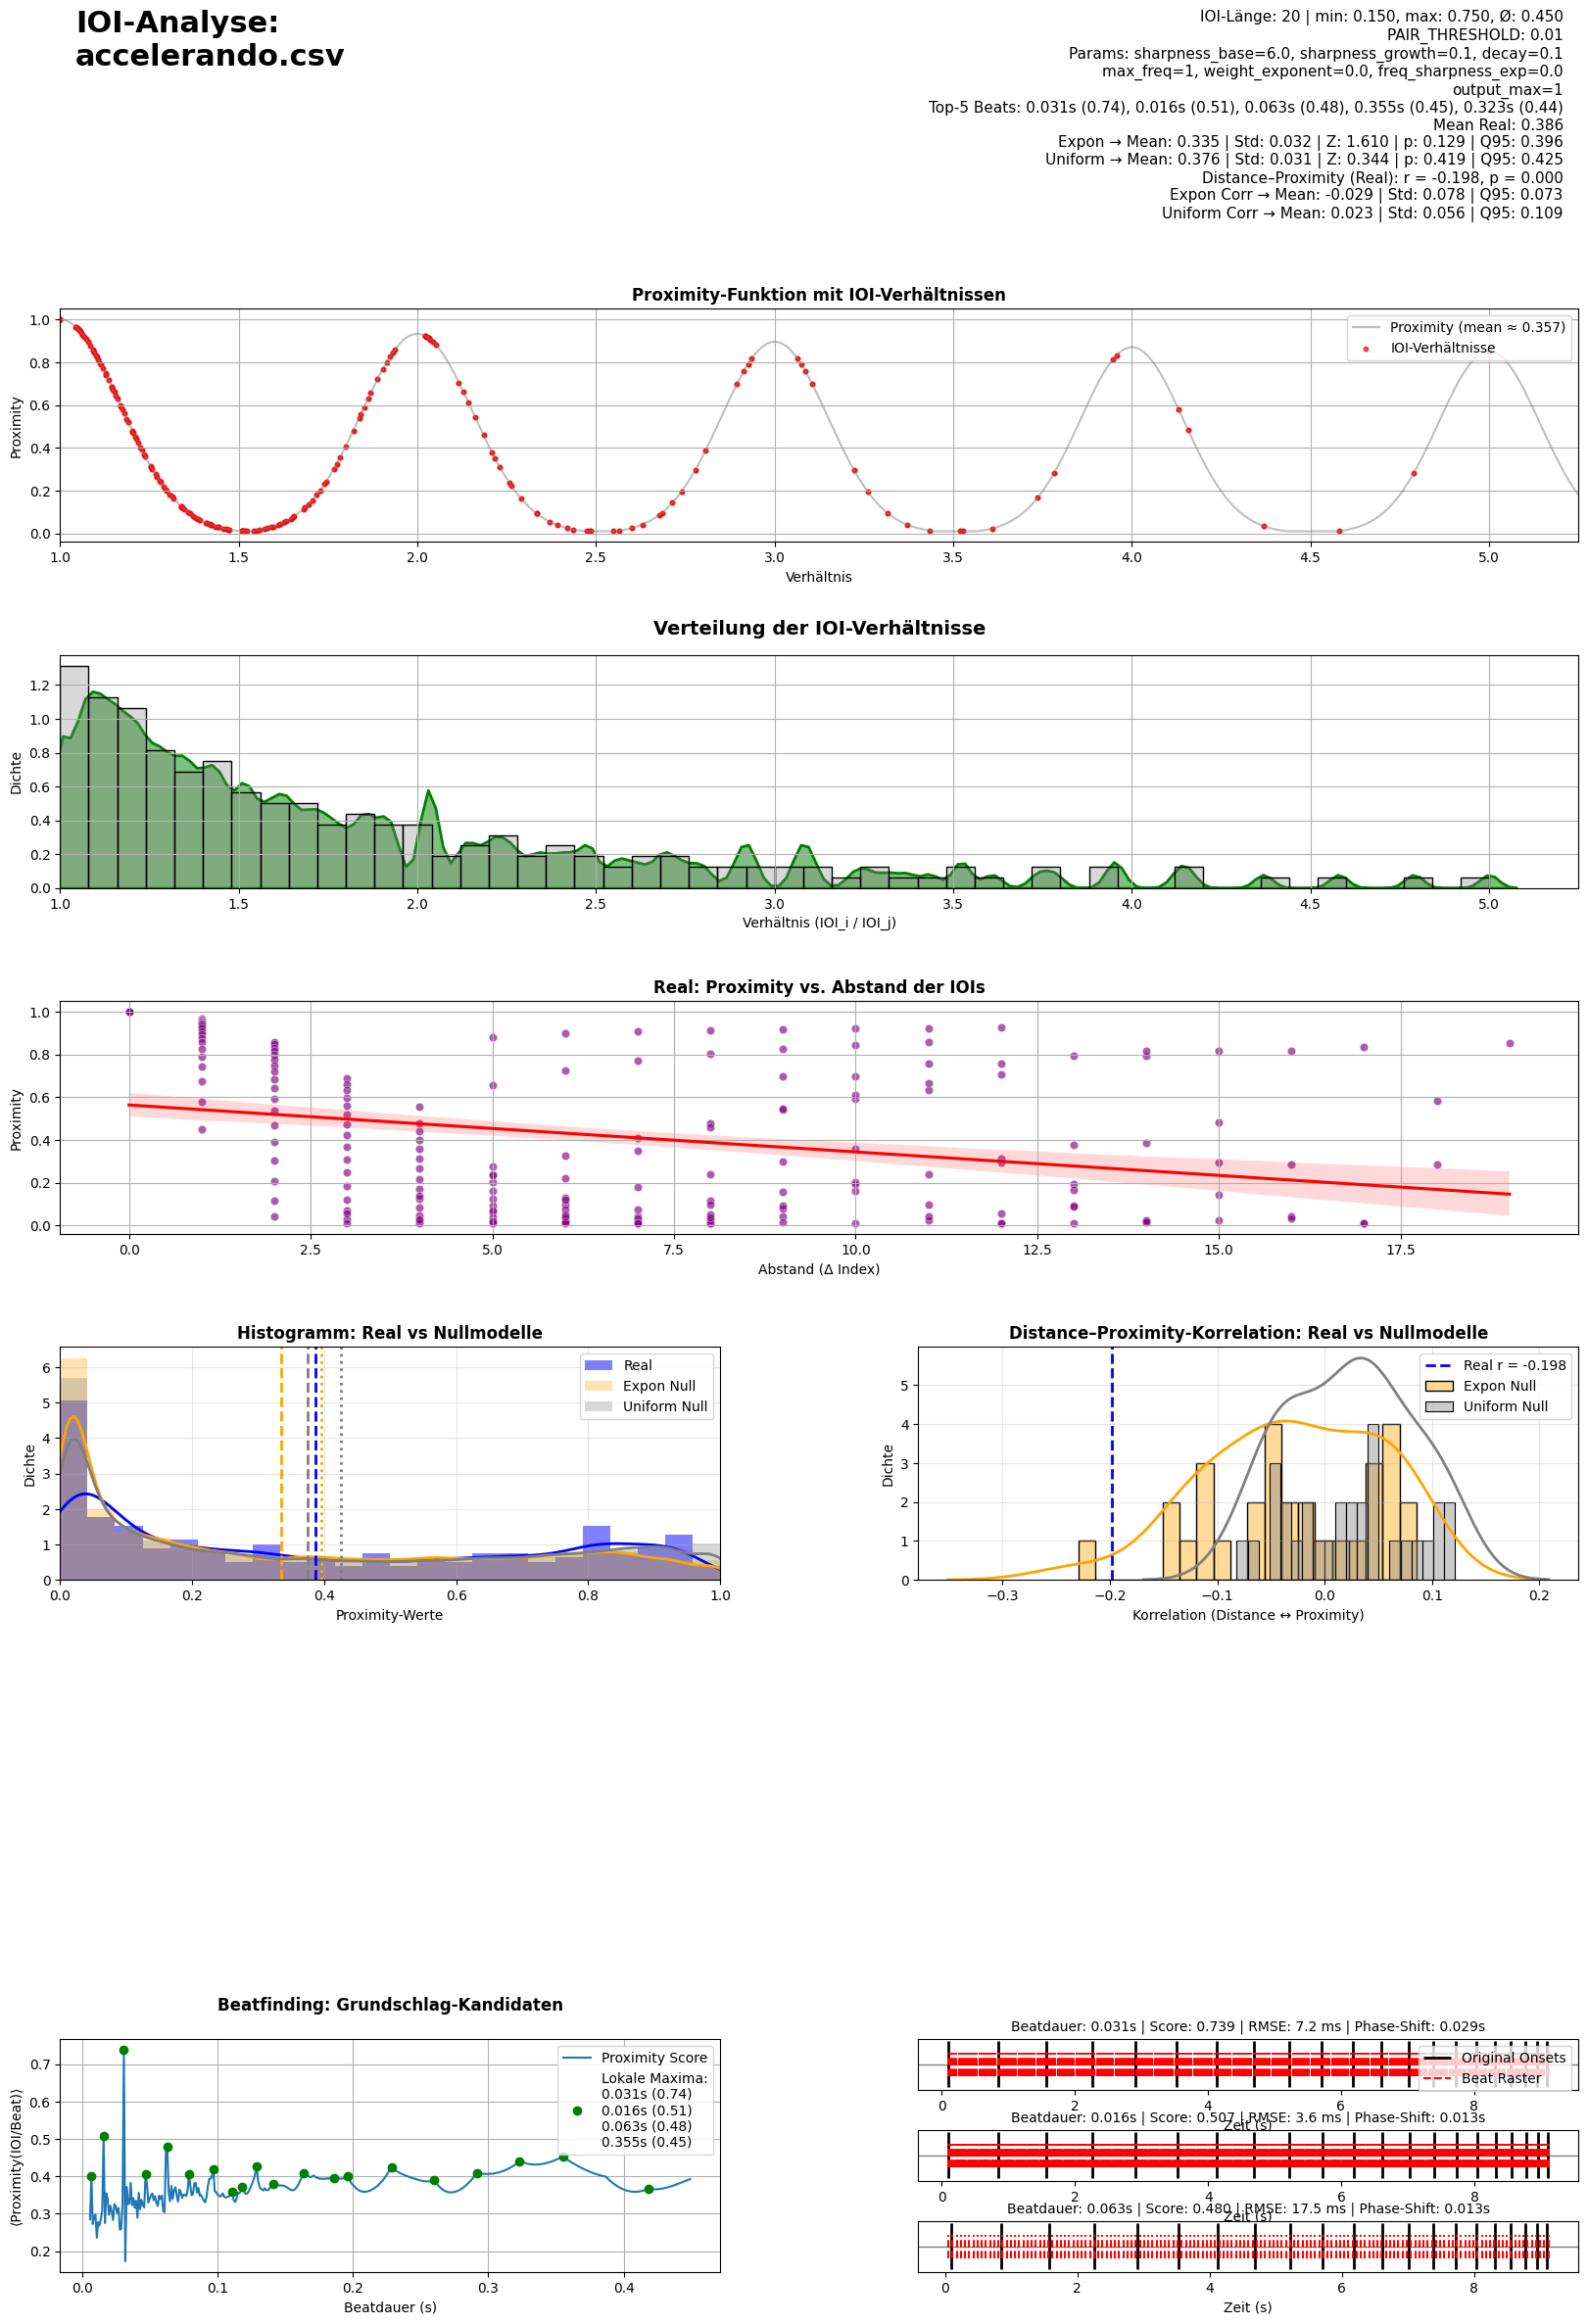


Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_15872/2540199011.py:639: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


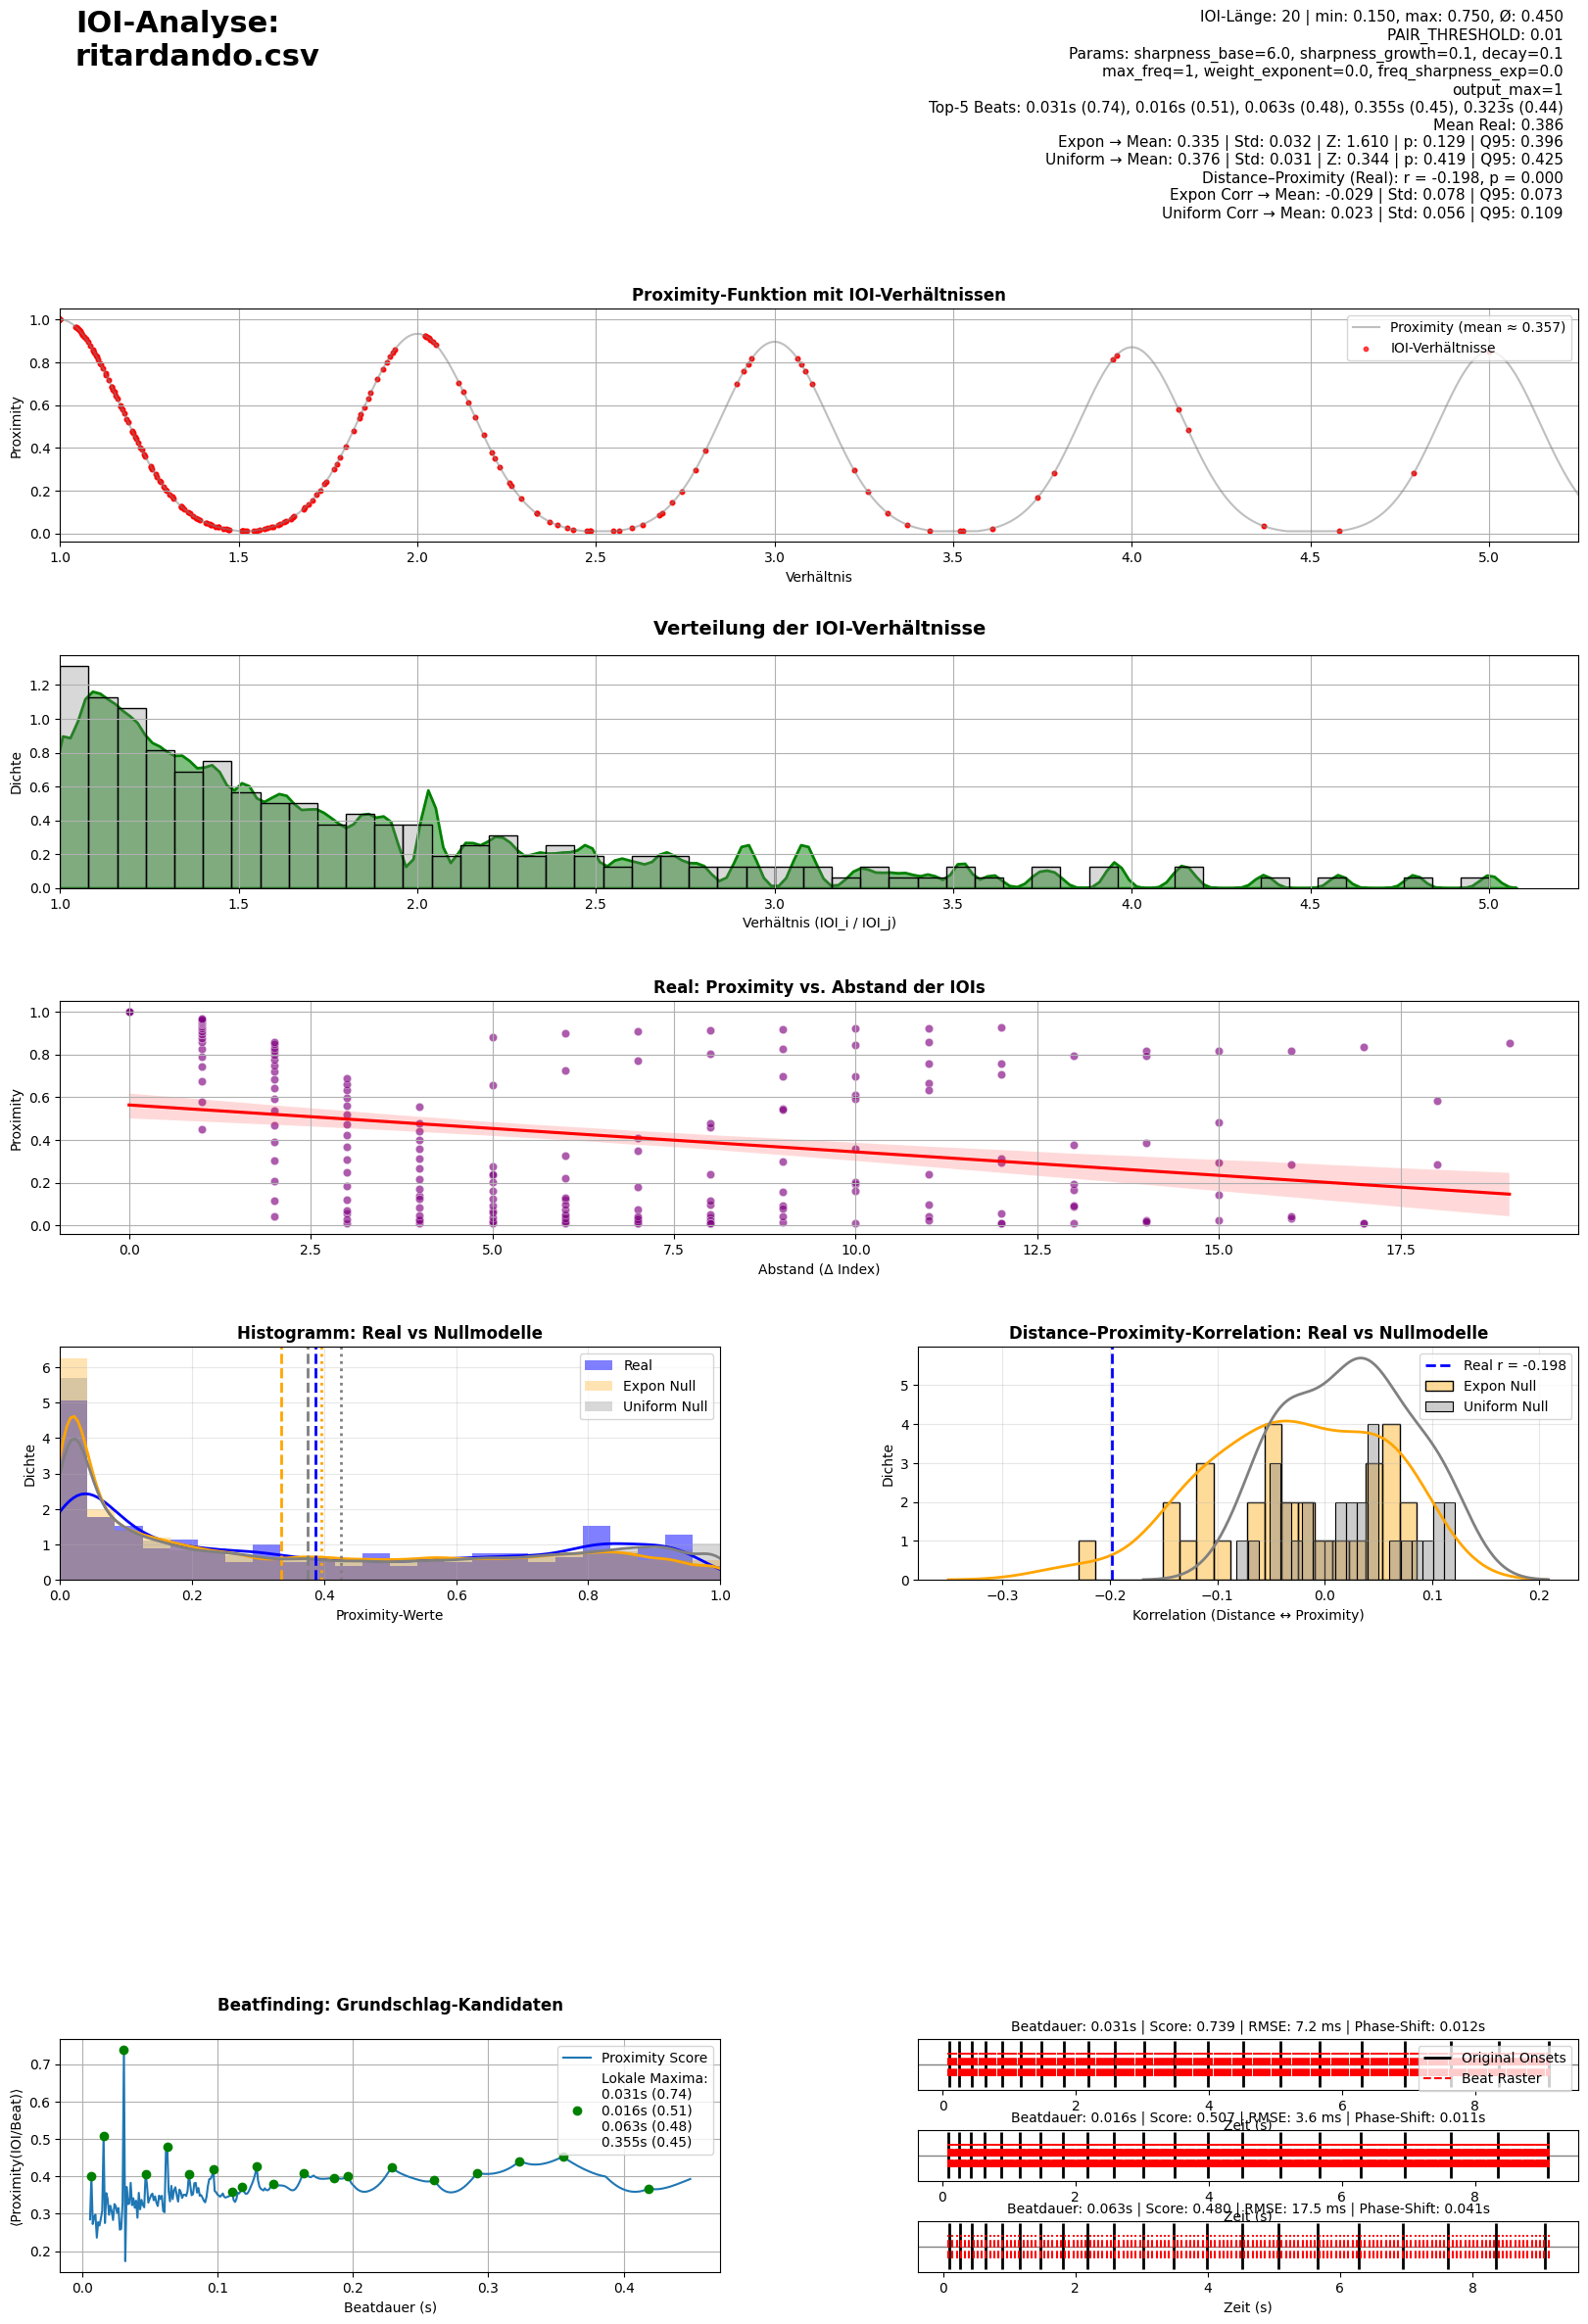


Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_15872/2540199011.py:639: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


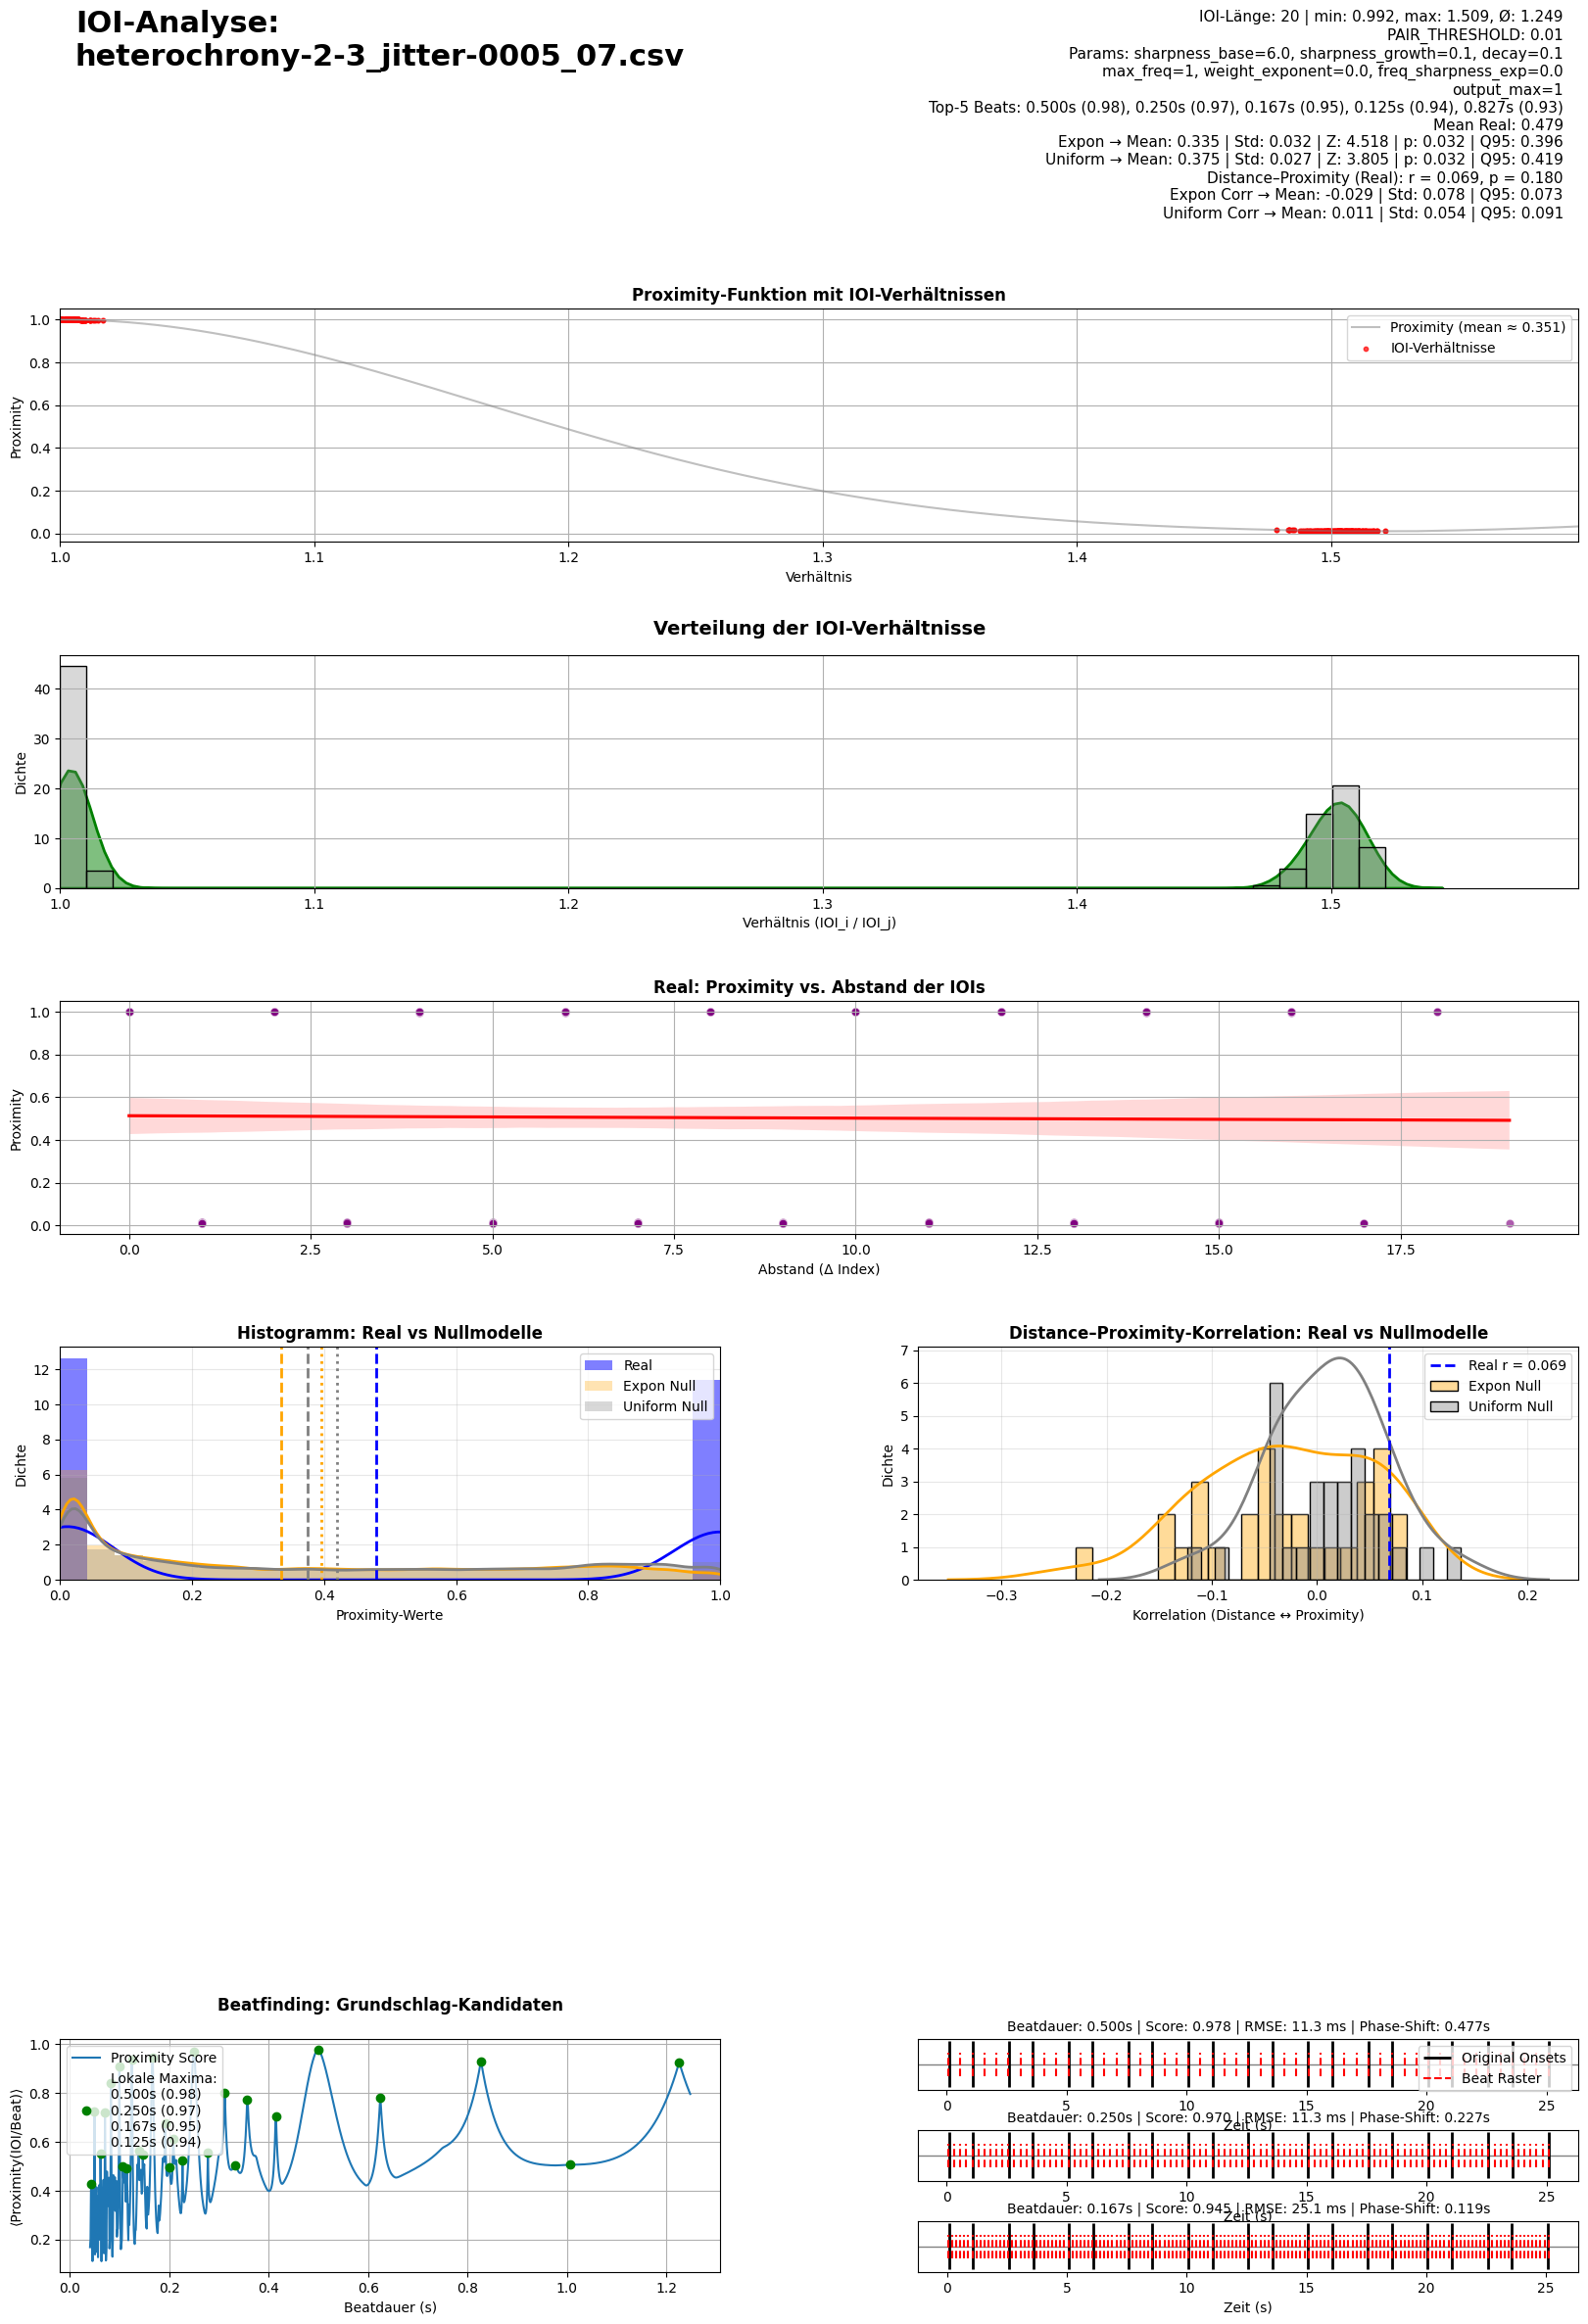


Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_15872/2540199011.py:639: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


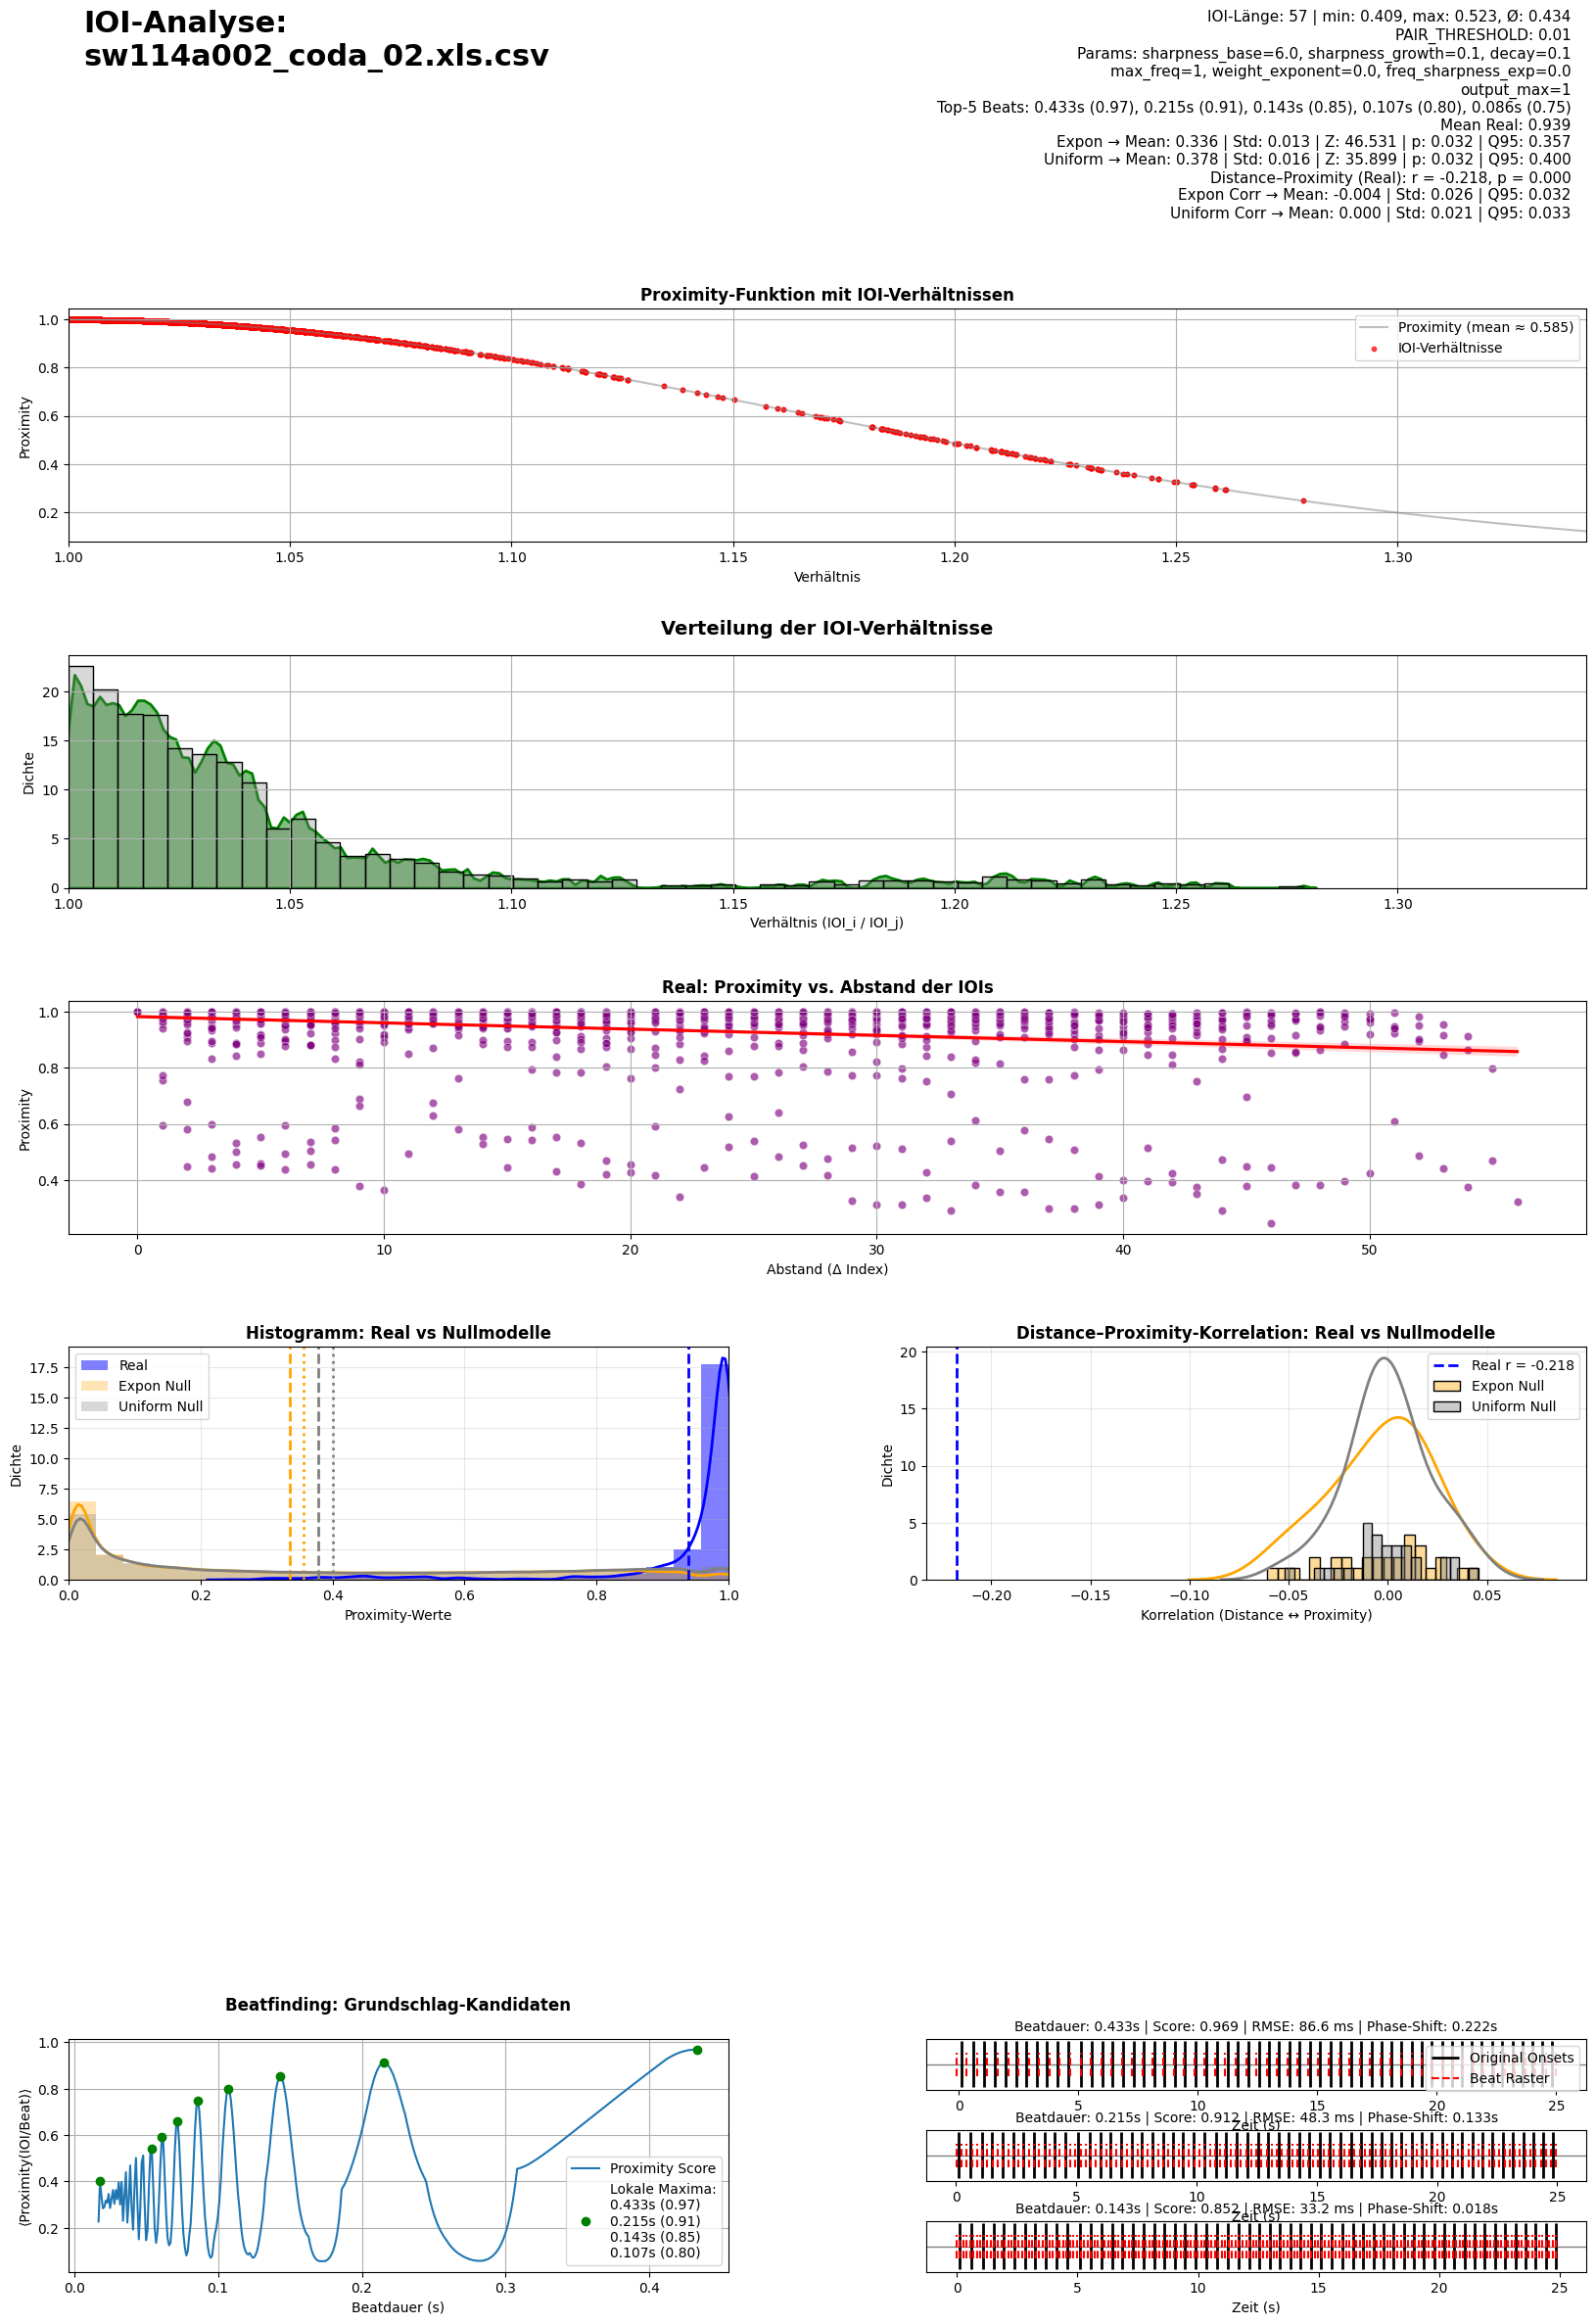


Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_15872/2540199011.py:639: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


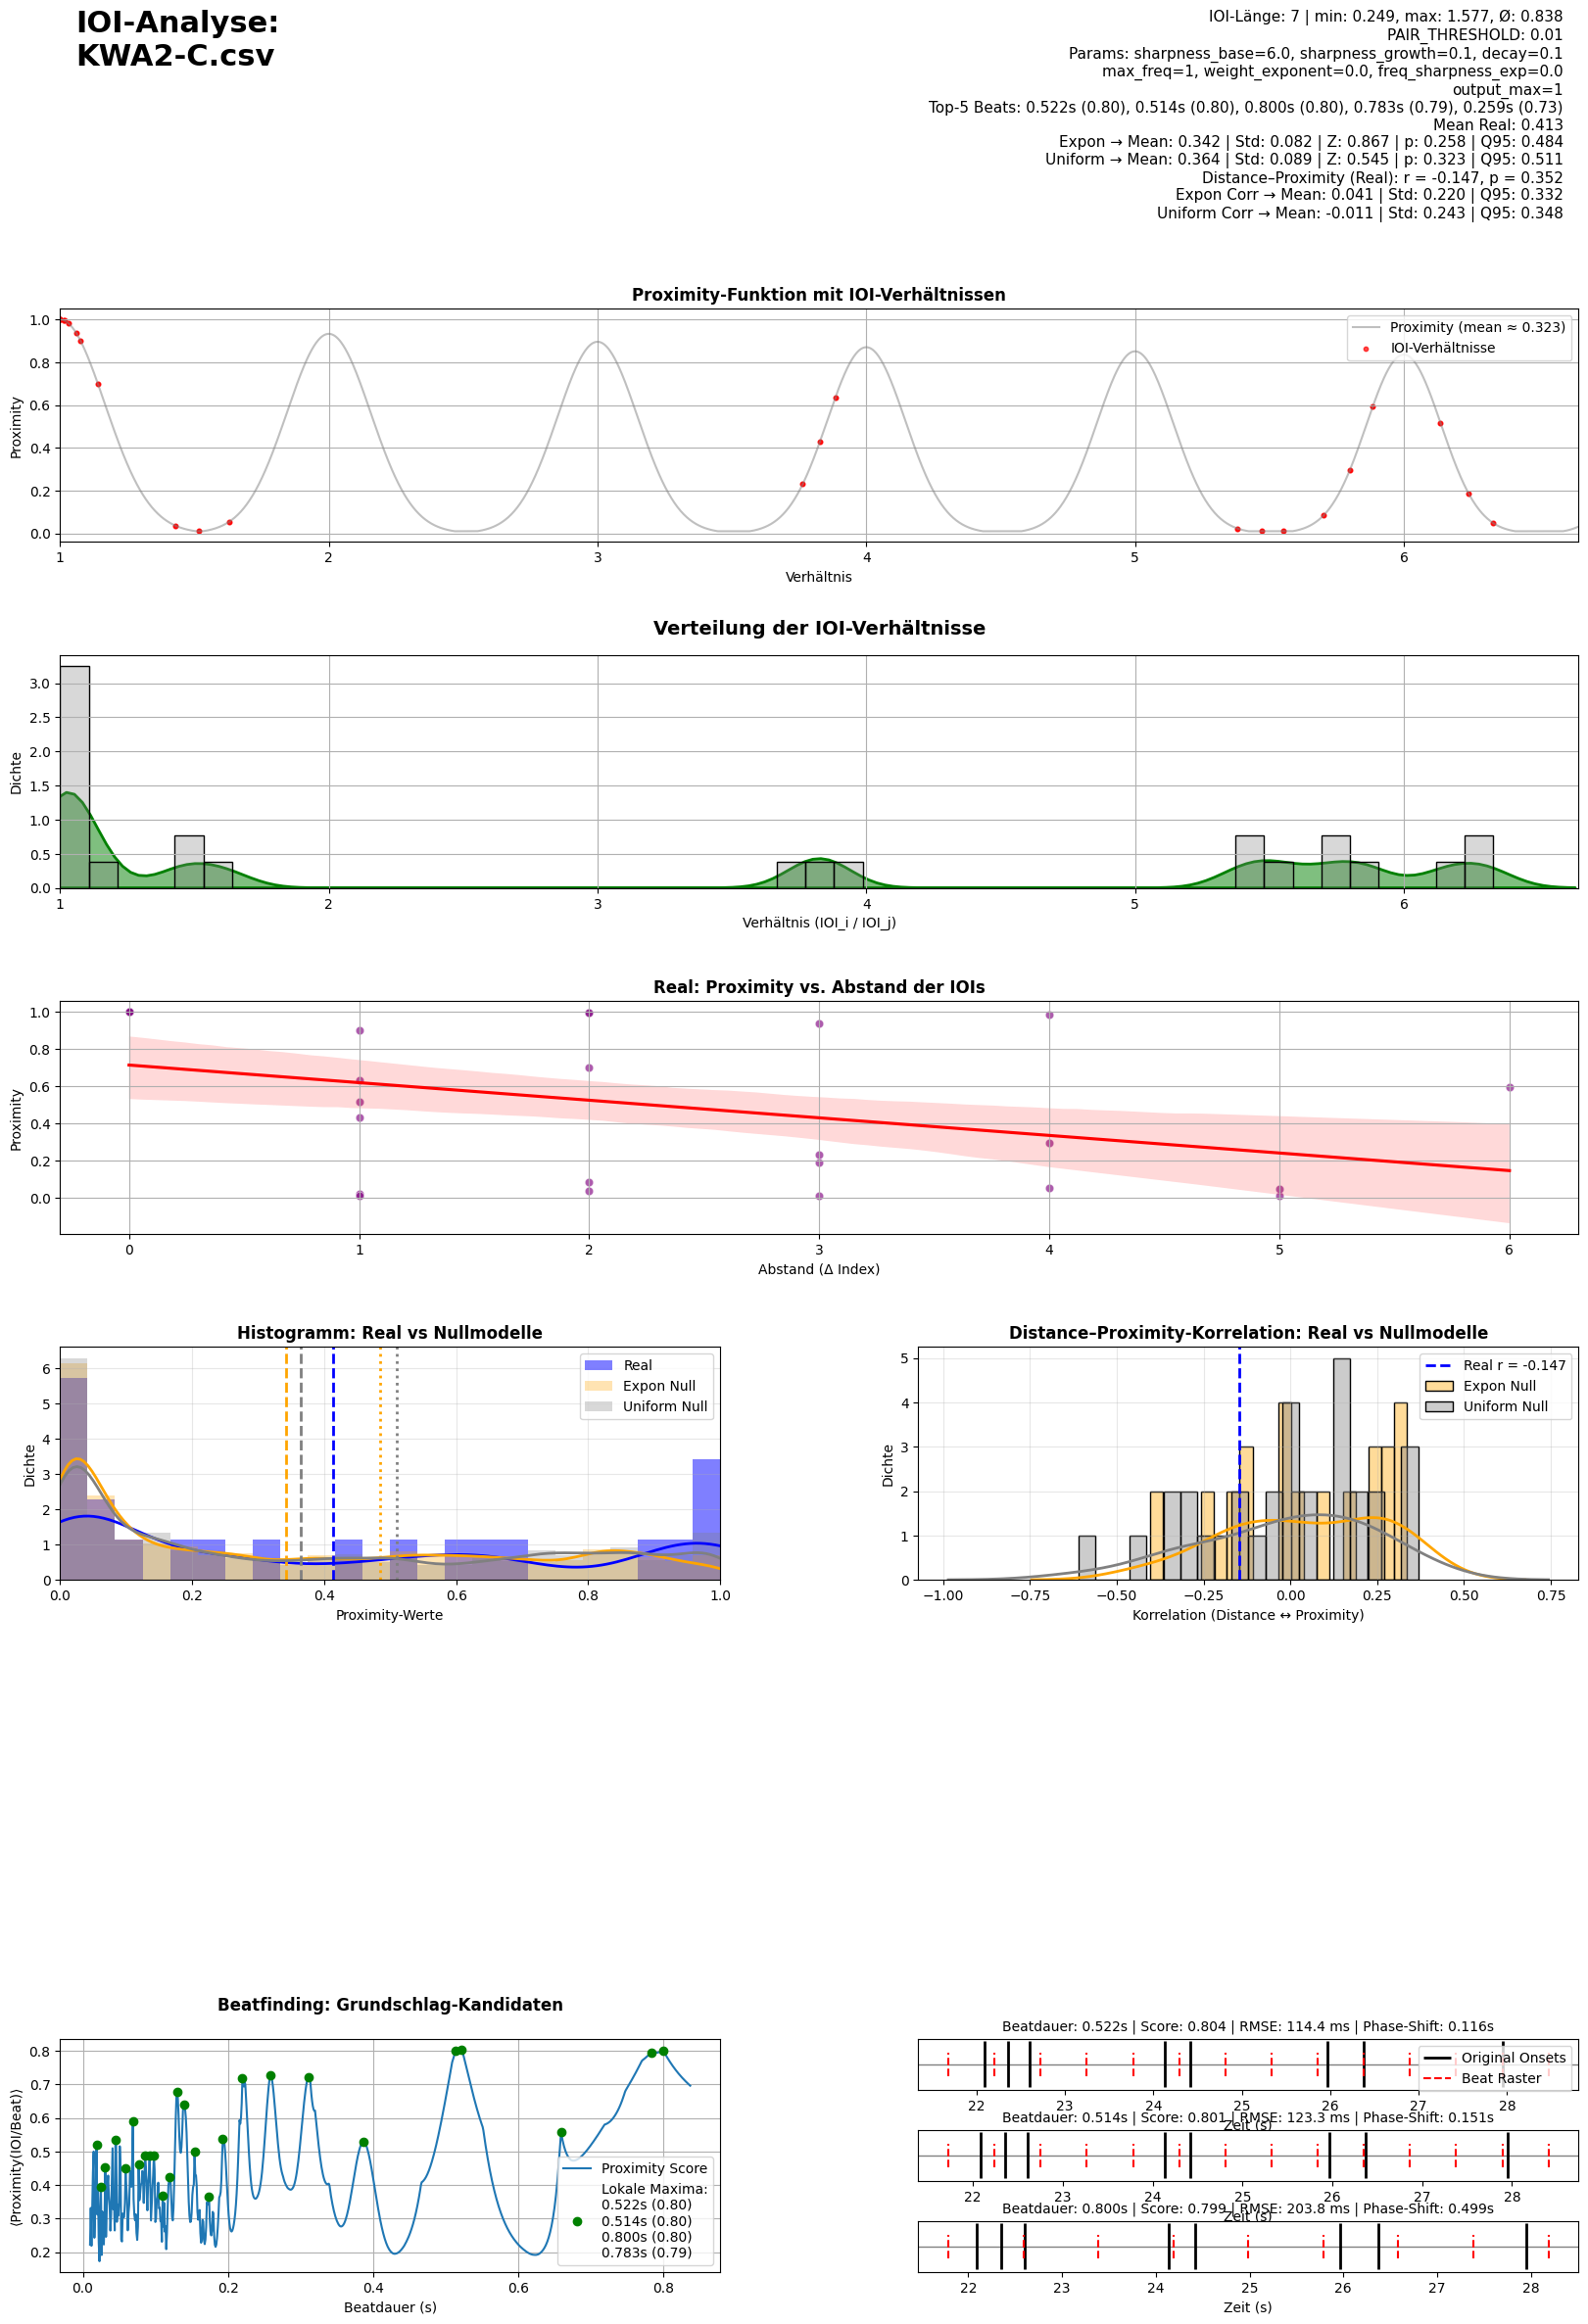


Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_15872/2540199011.py:639: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


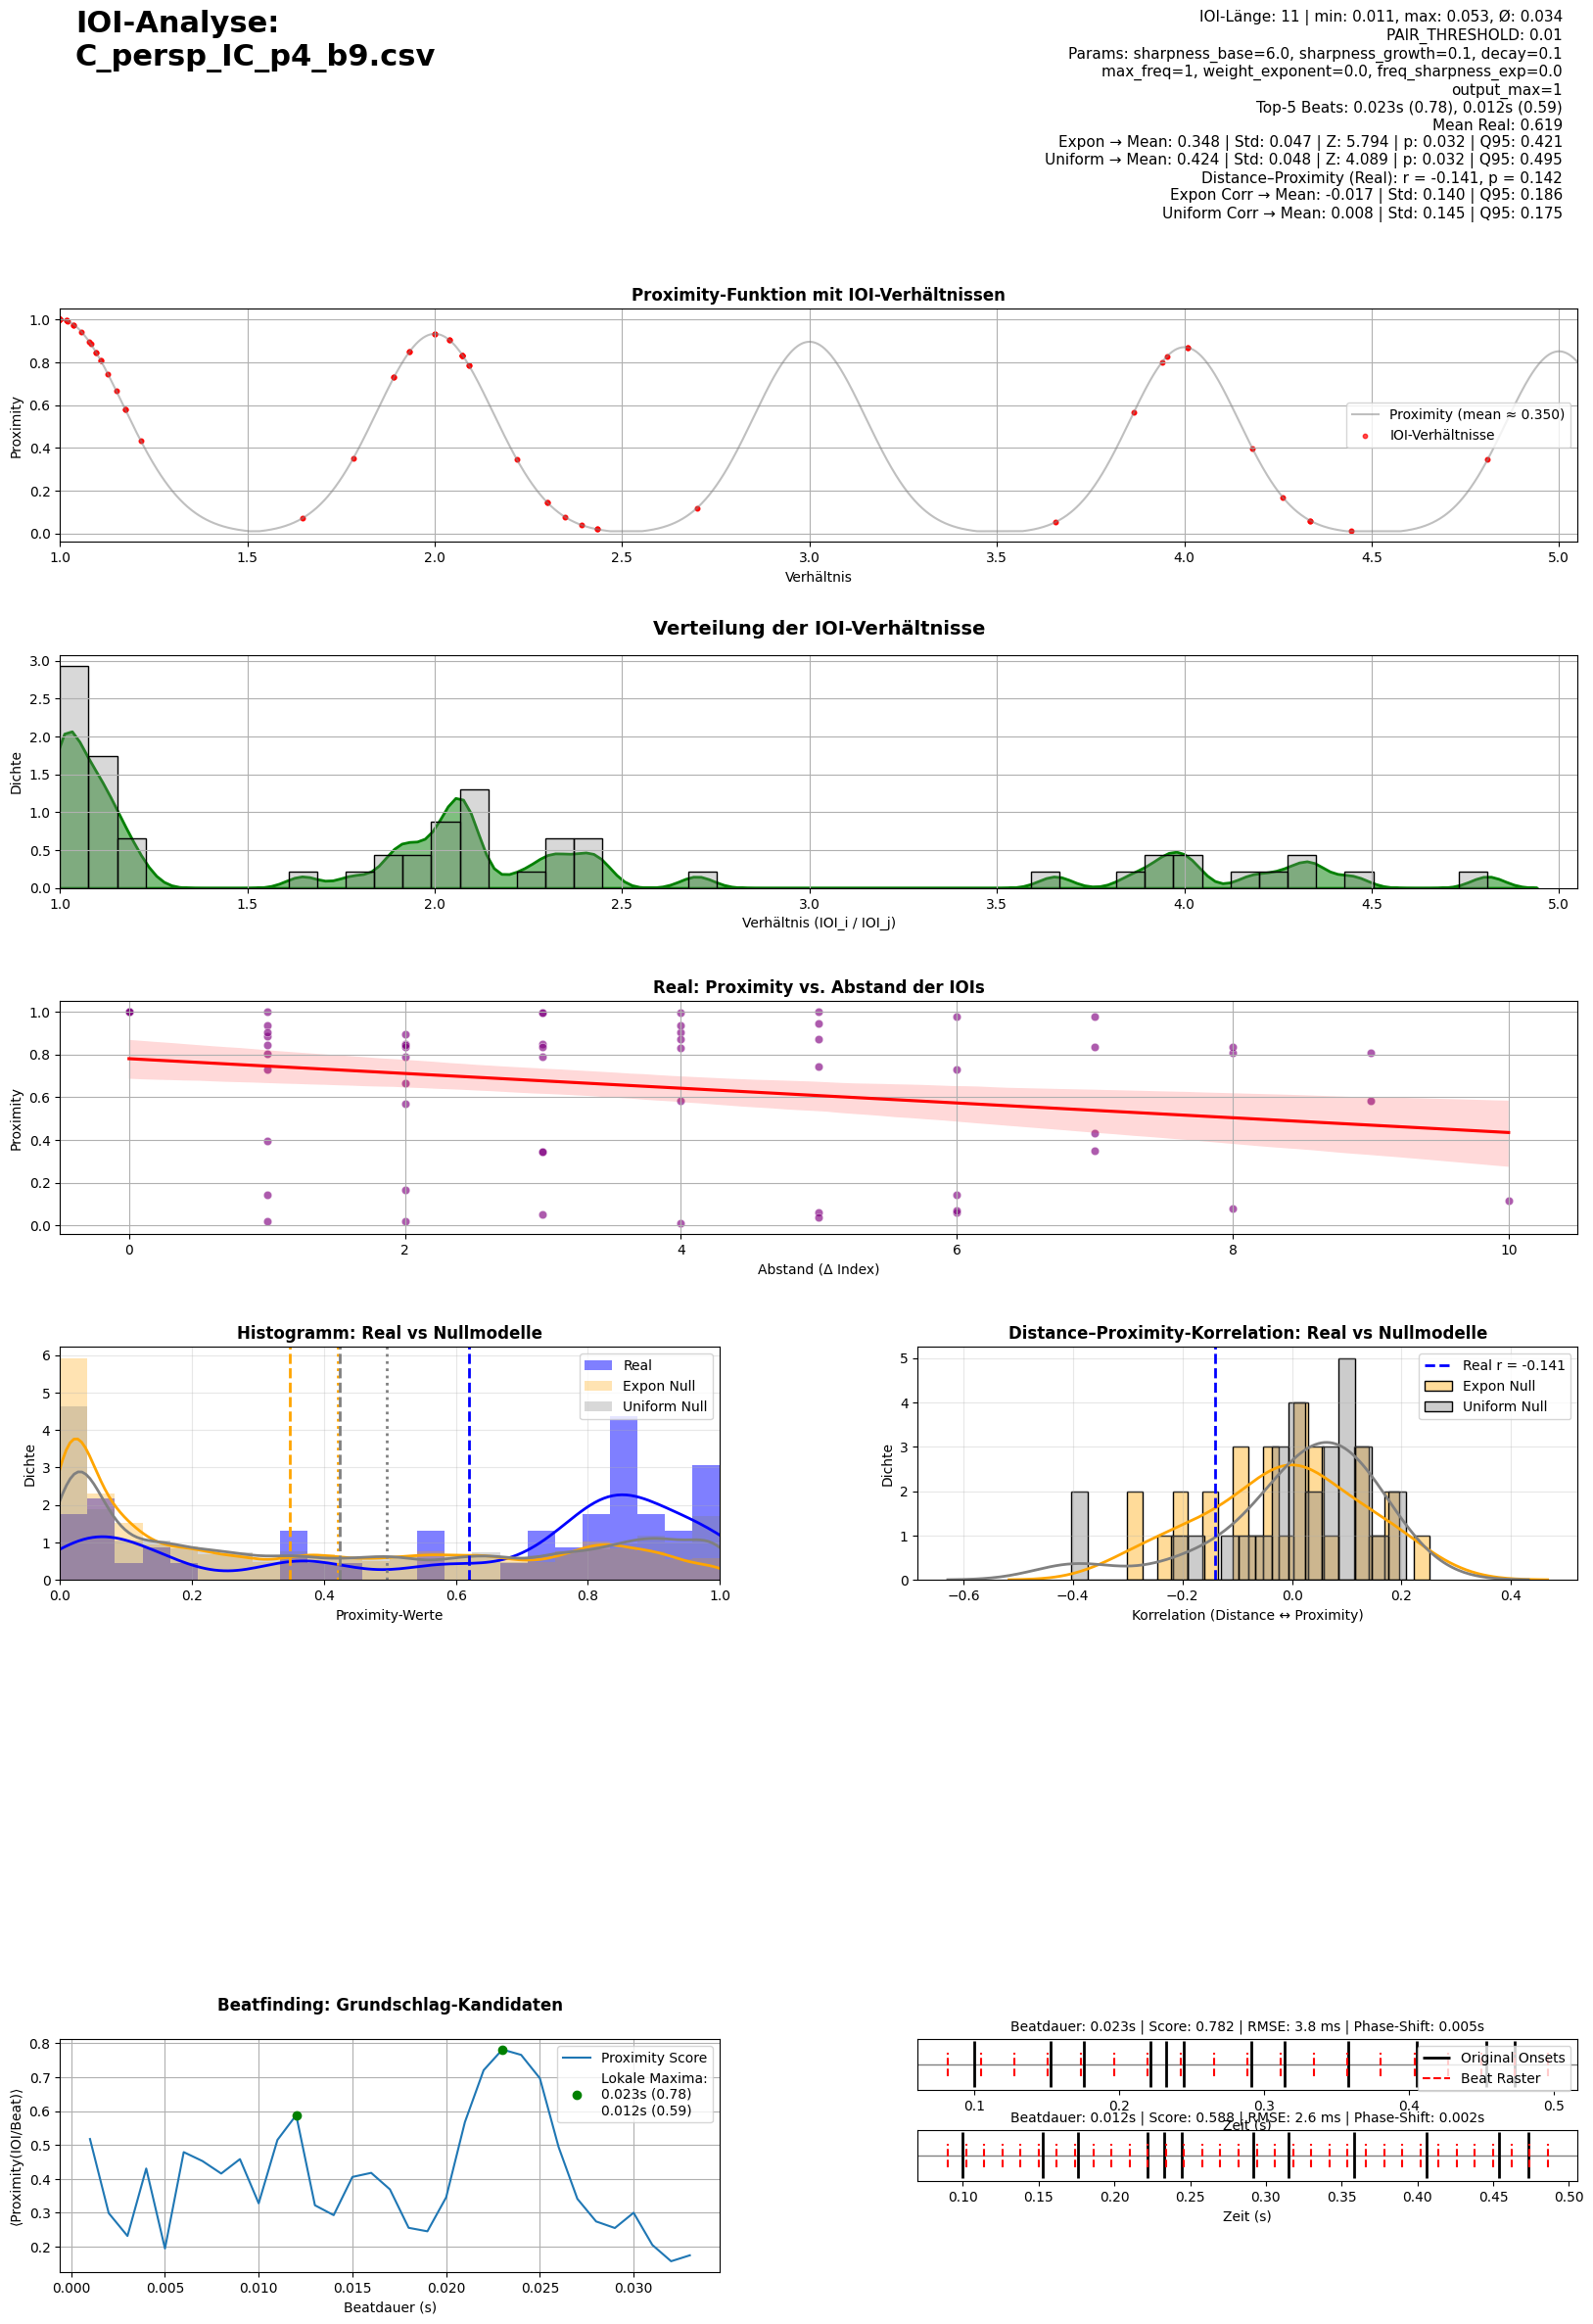

In [18]:

# ========================
# 0) Datei + Parameter Auswahl
# ========================
files = ["../data/theoretical_sequences/baseIOI-0.50/20beats/accelerando.csv",
         "../data/theoretical_sequences/baseIOI-0.50/20beats/ritardando.csv",
         "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0005_07.csv",
         "../data/Sperm whale Physeter macrocephalus (sw)/sw114a002_coda_02.xls.csv",
         "../data/Kwa-Sounds Scorpaena spp/KWA2-C.csv",
         "../data/Bat Carollia perspicillata (C_persp)/C_persp_IC_p4_b9.csv"
        ]

for file in files:
    for num in [2]: # choose 1, 2, 3, 4 or/and 5
        plot_sequence_analysis(
            filename=file.split("/")[-1],
            base_dir="/".join(file.split("/")[:-1]) + "/",
            param_choice=num,
            null_models=["expon", "uniform"],
            num_sequences=30,
            only_page=True,
            safe_fig=False,
            save_dir=False
        )